In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
import matplotlib as mpl

plt.style.use('sty.mplstyle')

atomic_mass_unit = 1.6605e-27 # kg
MAr = 39.95*atomic_mass_unit # Mass of argon in atomic mass units

def Compute_Trident_Events_Uncertainties(convXsec, MD, Int_Flux, POT):
    # convXsec should be given in fb
    # MD should be given in tonnes
    # POT should be given in units of 10^{21}
    # Int_Flux should be given in nu/m^2/POT
    Uncertainty = np.zeros_like(convXsec)
    for i in range(len(convXsec)):
        for j in range(len(convXsec[i])):
            Uncertainty[i][j] = 100*np.abs( 1 - convXsec[i][j]/convXsec[i][0] )
    NumOfEvents = Int_Flux * convXsec * MD/MAr * POT
    NumOfEvents = 1e-19*NumOfEvents
    return NumOfEvents, Uncertainty

# MiniBooNE

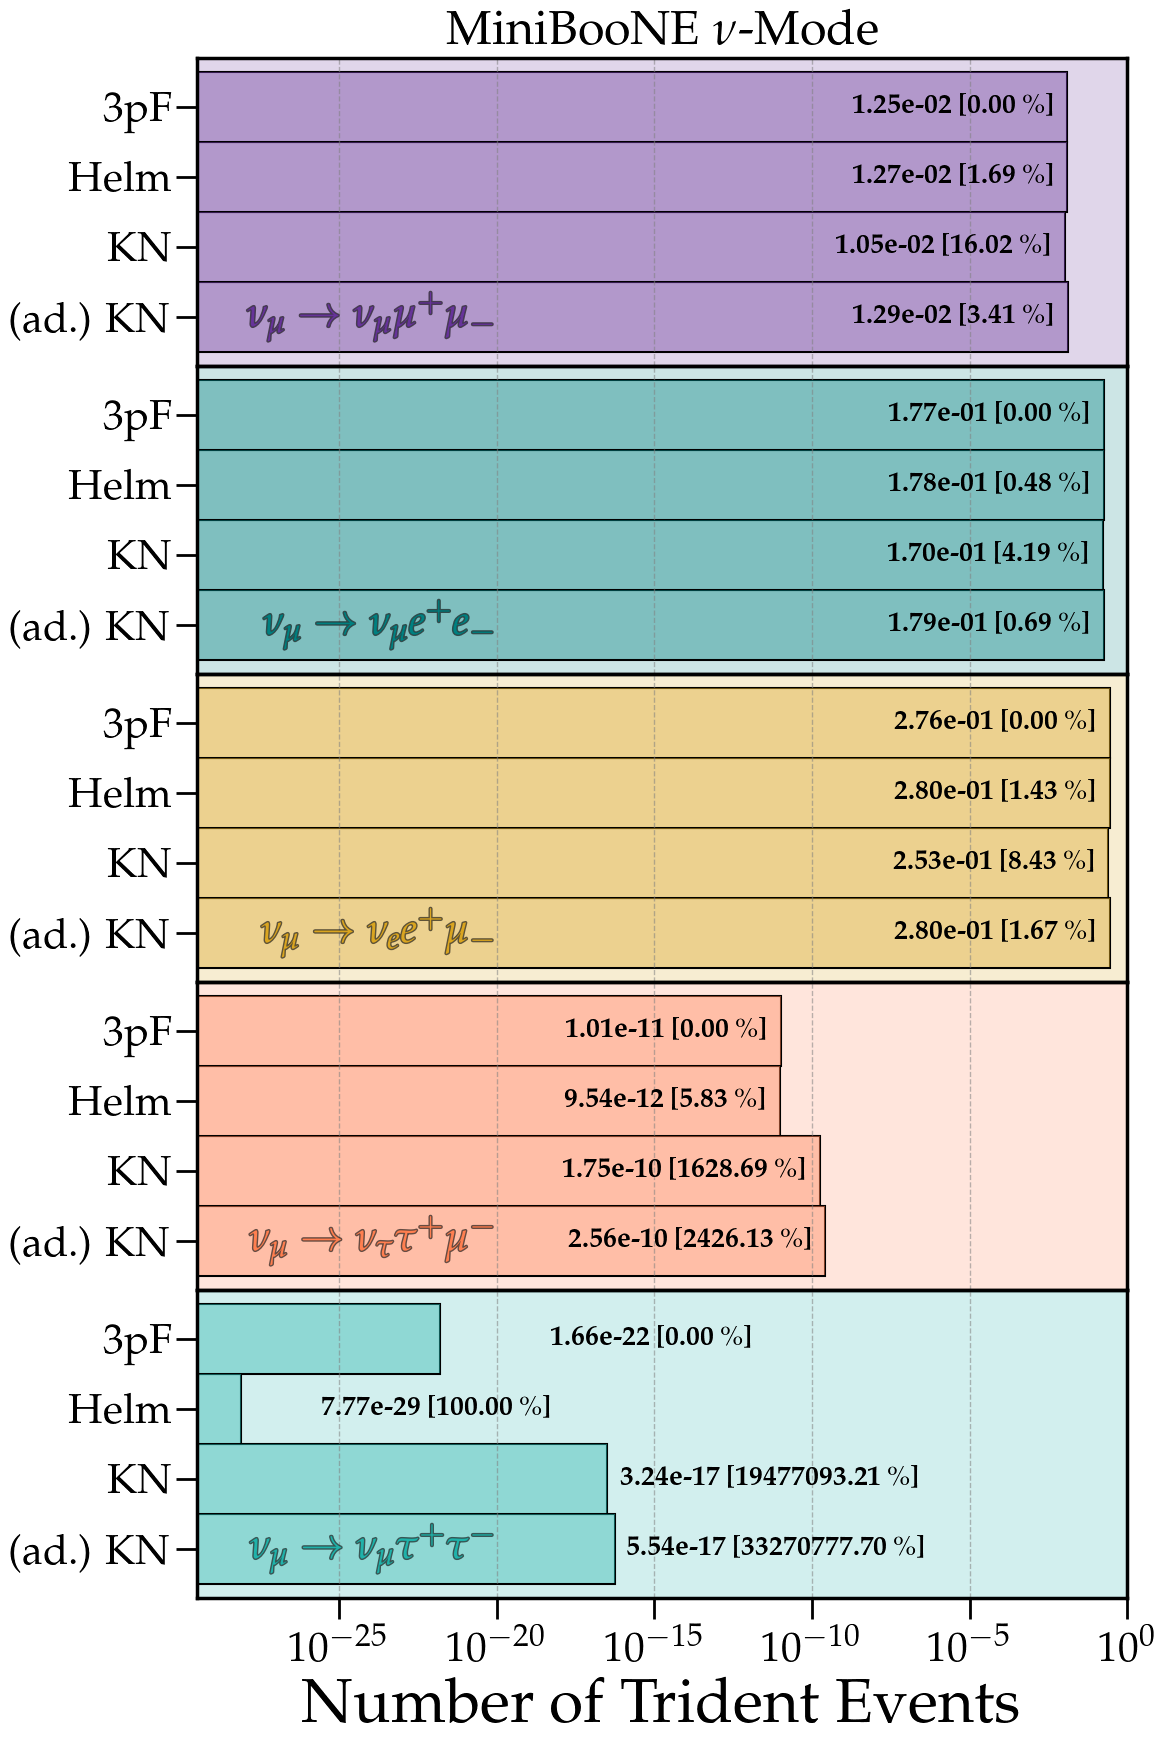

In [2]:
MD_MiniBooNE = 112
POT_MiniBooNE = 0.66
Total_Flux_MiniBooNE = 5.188231179736934e-06
ConvXsec_NuFlux_NuMode_MiniBooNE = np.loadtxt('../csv/Conv_CrossSections/ConvXsec_nuflux_nuMode_MiniBooNE')
NumOfEvents_NuFlux_NuMode_MiniBooNE, Uncertainty_NuFlux_NuMode_MiniBooNE = Compute_Trident_Events_Uncertainties(ConvXsec_NuFlux_NuMode_MiniBooNE, MD_MiniBooNE, Total_Flux_MiniBooNE, POT_MiniBooNE)

Form_Factors = ['3pF', 'Helm', 'KN', '(ad.) KN']
Processes = [r'{\bf $\nu_\mu \to \nu_\mu \mu^{+} \mu_{-}$}',
             r'{\bf $\nu_\mu \to \nu_\mu e^{+} e_{-}$}',
             r'{\bf $\nu_\mu \to \nu_e e^{+} \mu_{-}$}',
             r'{\bf $\nu_\mu \to \nu_\tau \tau^{+} \mu^{-}$}',
             r'{\bf $\nu_\mu \to \nu_\mu \tau^{+} \tau^{-}$}']
Number_FormFactors = len(Form_Factors)
Number_Processes = len(Processes)

fig = plt.figure(figsize=(12,20))
gs = fig.add_gridspec(Number_Processes, hspace=0)
ax = gs.subplots(sharex=True, sharey=True)
cols = ['rebeccapurple', 'teal', 'goldenrod', 'coral', 'lightseagreen']

for i in range(len(NumOfEvents_NuFlux_NuMode_MiniBooNE)):
    data = NumOfEvents_NuFlux_NuMode_MiniBooNE[i]
    ax[i].barh(np.flipud(Form_Factors), np.flipud(data), left=0, align='center', height=1, edgecolor='k', facecolor='w', lw=1.5, zorder=-10, alpha=1)
    ax[i].barh(np.flipud(Form_Factors), np.flipud(data), left=0, xerr=0, align='center', height=0.98, facecolor=cols[i], lw=0, zorder=-10, alpha=0.5)
    ax[i].patch.set_facecolor(cols[i])
    ax[i].patch.set_alpha(0.2)


Correct_Position_Events = [0.4, 0.4, 0.4, 0.4, 8e9]
for i in range(len(NumOfEvents_NuFlux_NuMode_MiniBooNE)):
    for j in range(len(NumOfEvents_NuFlux_NuMode_MiniBooNE[0])):
        ax[i].text(Correct_Position_Events[i] * NumOfEvents_NuFlux_NuMode_MiniBooNE[i][j], Number_FormFactors-1-j, r'{\bf %.2e [%.2f $\%%$]}' %
                   (NumOfEvents_NuFlux_NuMode_MiniBooNE[i][j], Uncertainty_NuFlux_NuMode_MiniBooNE[i][j]), va='center', ha='right', fontsize=20)


for i in range(len(ax)):
    ax[i].xaxis.grid(True, linestyle='--', which='major', color='grey', alpha=0.55)
    ax[i].tick_params(which='both', right=False, tickdir='out', top=False, bottom=False)
ax[-1].tick_params(which='both', right=False, tickdir='out', top=False, bottom=True)

for i in range(Number_Processes):
    ax[i].text(1e-20, 0, Processes[i], fontsize=30, alpha=1, color=cols[i], va='center', ha='right', rotation=0, path_effects=[pe.Stroke(linewidth=2, foreground='k', alpha=0.6), pe.Normal()])

ax[0].set_title(r'MiniBooNE $\nu$-Mode')
ax[-1].set_xlabel(r'Number of Trident Events')
ax[-1].set_xscale('log')
ax[-1].set_xlim(right=1)

plt.savefig(r'../Plots/Figures_PDF/EventsatMiniBooNE_NuFlux_NuMode.pdf', transparent=False, bbox_inches='tight')
plt.savefig(r'../Plots/Figures_PNG/EventsatMiniBooNE_NuFlux_NuMode.png', transparent=False, bbox_inches='tight')

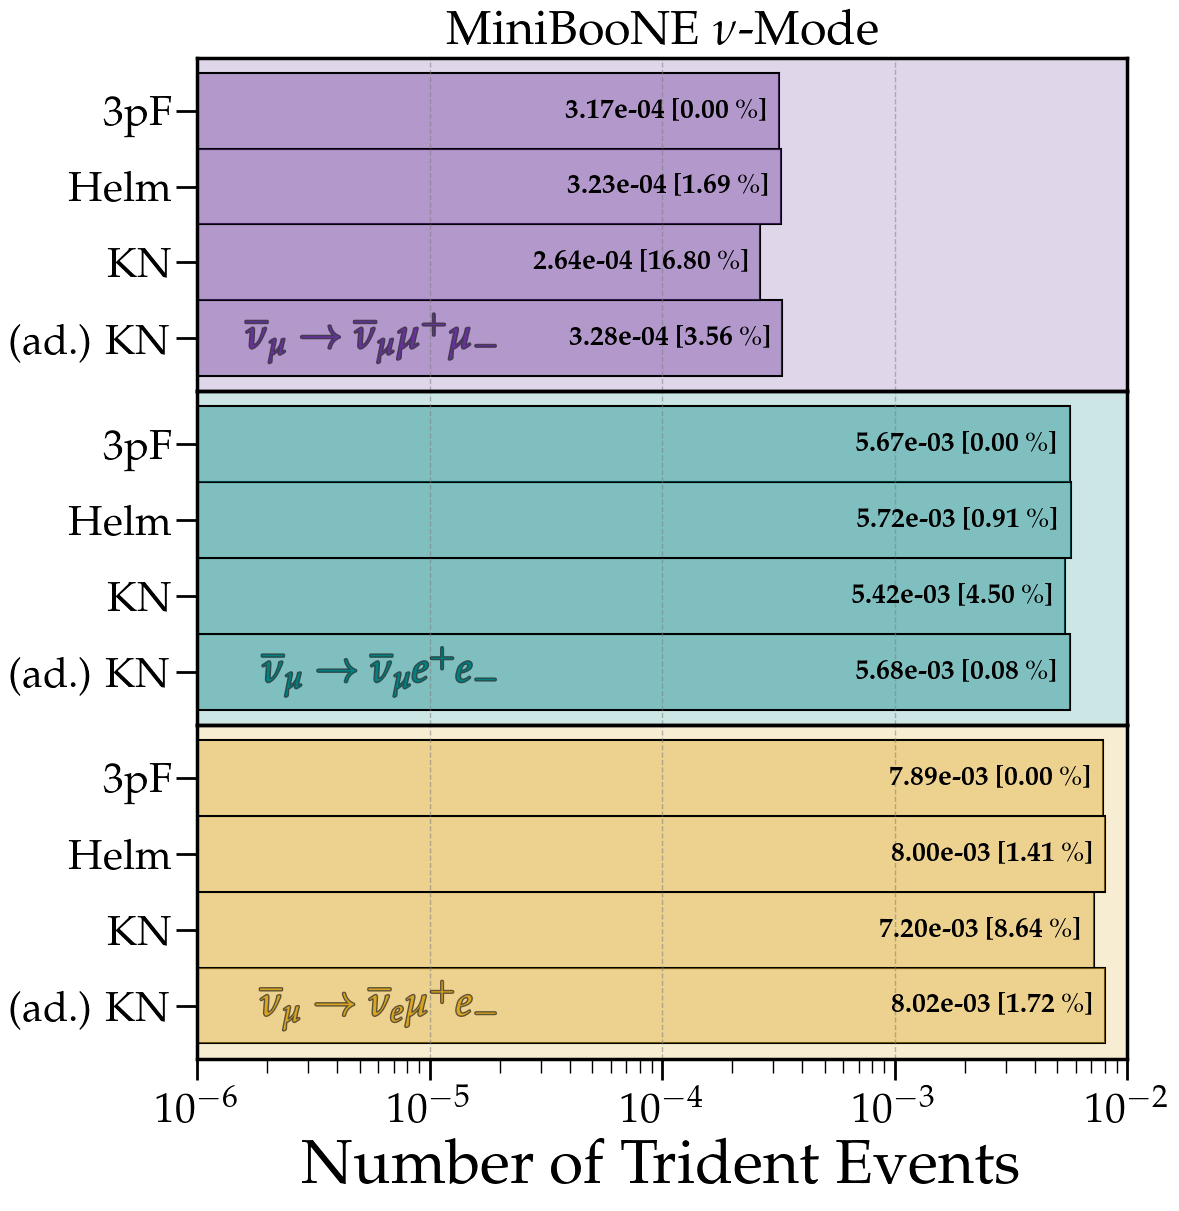

In [3]:
MD_MiniBooNE = 112
POT_MiniBooNE = 0.66
Total_Flux_MiniBooNE = 3.205341386277867e-07
ConvXsec_AntiNuFlux_NuMode_MiniBooNE = np.loadtxt('../csv/Conv_CrossSections/ConvXsec_antinuflux_nuMode_MiniBooNE')
NumOfEvents_AntiNuFlux_NuMode_MiniBooNE, Uncertainty_AntiNuFlux_NuMode_MiniBooNE = Compute_Trident_Events_Uncertainties(ConvXsec_AntiNuFlux_NuMode_MiniBooNE, MD_MiniBooNE, Total_Flux_MiniBooNE, POT_MiniBooNE)

Form_Factors = ['3pF', 'Helm', 'KN', '(ad.) KN']
Processes = [r'{\bf $\overline{\nu}_\mu \to \overline{\nu}_\mu \mu^{+} \mu_{-}$}',
             r'{\bf $\overline{\nu}_\mu \to \overline{\nu}_\mu e^{+} e_{-}$}',
             r'{\bf $\overline{\nu}_\mu \to \overline{\nu}_e \mu^{+} e_{-}$}']
Number_FormFactors = len(Form_Factors)
Number_Processes = len(Processes)

fig = plt.figure(figsize=(12,13))
gs = fig.add_gridspec(Number_Processes, hspace=0)
ax = gs.subplots(sharex=True, sharey=True)
cols = ['rebeccapurple', 'teal', 'goldenrod']

for i in range(len(NumOfEvents_AntiNuFlux_NuMode_MiniBooNE)):
    data = NumOfEvents_AntiNuFlux_NuMode_MiniBooNE[i]
    ax[i].barh(np.flipud(Form_Factors), np.flipud(data), left=0, align='center', height=1, edgecolor='k', facecolor='w', lw=1.5, zorder=-10, alpha=1)
    ax[i].barh(np.flipud(Form_Factors), np.flipud(data), left=0, xerr=0, align='center', height=0.98, facecolor=cols[i], lw=0, zorder=-10, alpha=0.5)
    ax[i].patch.set_facecolor(cols[i])
    ax[i].patch.set_alpha(0.2)


Correct_Position_Events = [0.9, 0.9, 0.9]
for i in range(len(NumOfEvents_AntiNuFlux_NuMode_MiniBooNE)):
    for j in range(len(NumOfEvents_AntiNuFlux_NuMode_MiniBooNE[0])):
        ax[i].text(Correct_Position_Events[i] * NumOfEvents_AntiNuFlux_NuMode_MiniBooNE[i][j], Number_FormFactors-1-j, r'{\bf %.2e [%.2f $\%%$]}' %
                   (NumOfEvents_AntiNuFlux_NuMode_MiniBooNE[i][j], Uncertainty_AntiNuFlux_NuMode_MiniBooNE[i][j]), va='center', ha='right', fontsize=20)


for i in range(len(ax)):
    ax[i].xaxis.grid(True, linestyle='--', which='major', color='grey', alpha=0.55)
    ax[i].tick_params(which='both', right=False, tickdir='out', top=False, bottom=False)
ax[-1].tick_params(which='both', right=False, tickdir='out', top=False, bottom=True)

for i in range(Number_Processes):
    ax[i].text(2e-5, 0, Processes[i], fontsize=30, alpha=1, color=cols[i], va='center', ha='right', rotation=0, path_effects=[pe.Stroke(linewidth=2, foreground='k', alpha=0.6), pe.Normal()])

ax[0].set_title(r'MiniBooNE $\nu$-Mode')
ax[-1].set_xlabel(r'Number of Trident Events')
ax[-1].set_xscale('log')
ax[-1].set_xlim(left=1e-6, right=1e-2)

plt.savefig(r'../Plots/Figures_PDF/EventsatMiniBooNE_AntiNuFlux_NuMode.pdf', transparent=False, bbox_inches='tight')
plt.savefig(r'../Plots/Figures_PNG/EventsatMiniBooNE_AntiNuFlux_NuMode.png', transparent=False, bbox_inches='tight')

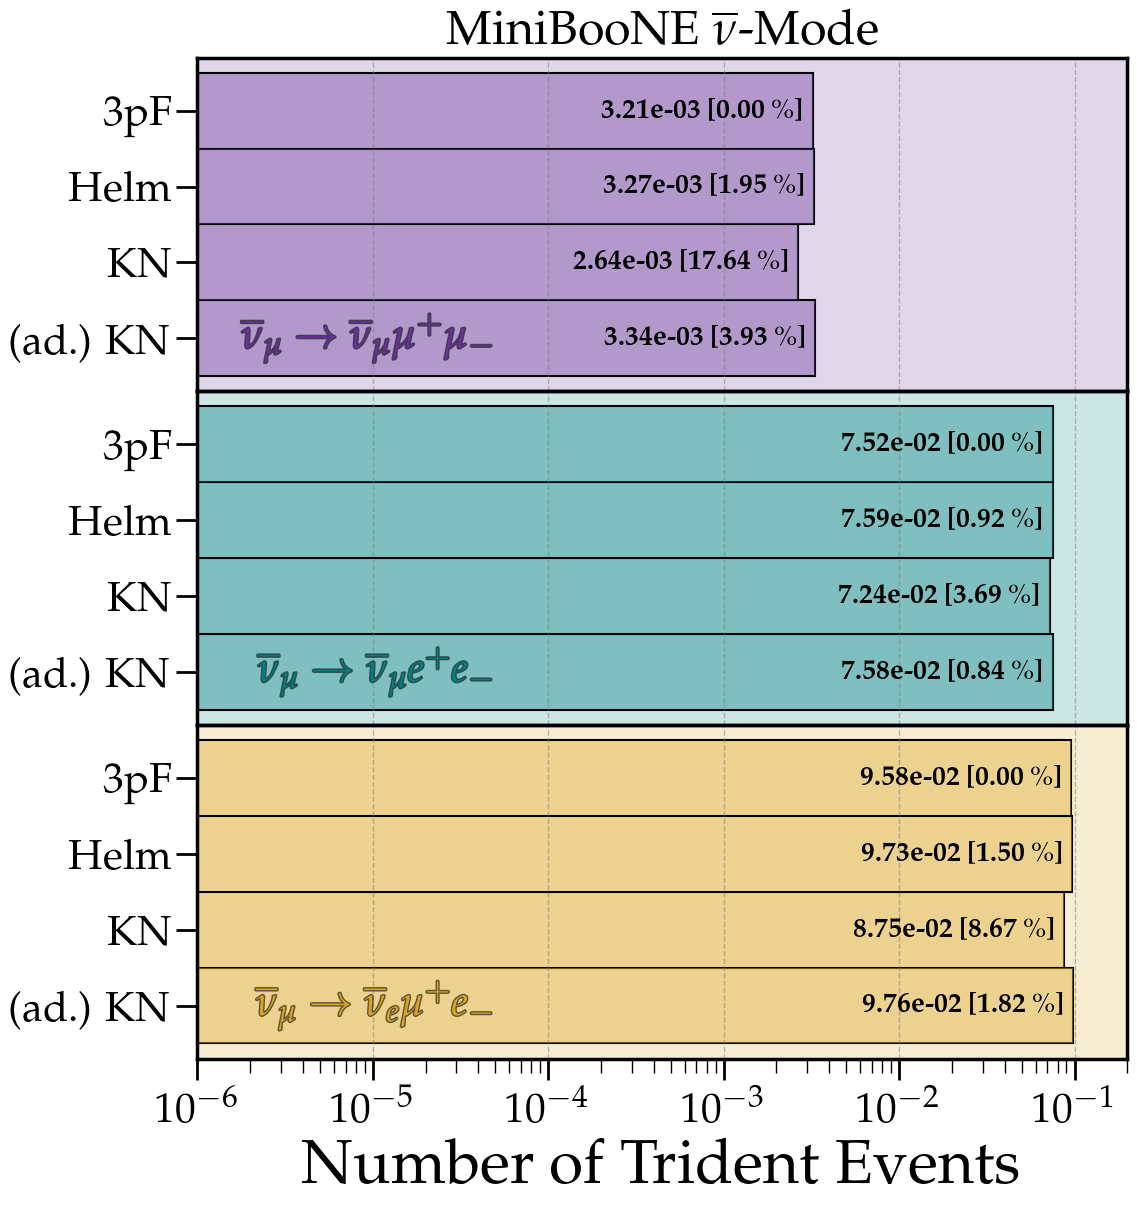

In [4]:
MD_MiniBooNE = 112
POT_MiniBooNE = 0.66
Total_Flux_MiniBooNE = 2.9249541426034934e-06
ConvXsec_AntiNuFlux_AntiNuMode_MiniBooNE = np.loadtxt('../csv/Conv_CrossSections/ConvXsec_antinuflux_antinuMode_MiniBooNE')
NumOfEvents_AntiNuFlux_AntiNuMode_MiniBooNE, Uncertainty_AntiNuFlux_AntiNuMode_MiniBooNE = Compute_Trident_Events_Uncertainties(ConvXsec_AntiNuFlux_AntiNuMode_MiniBooNE, MD_MiniBooNE, Total_Flux_MiniBooNE, POT_MiniBooNE)

Form_Factors = ['3pF', 'Helm', 'KN', '(ad.) KN']
Processes = [r'{\bf $\overline{\nu}_\mu \to \overline{\nu}_\mu \mu^{+} \mu_{-}$}',
             r'{\bf $\overline{\nu}_\mu \to \overline{\nu}_\mu e^{+} e_{-}$}',
             r'{\bf $\overline{\nu}_\mu \to \overline{\nu}_e \mu^{+} e_{-}$}']
Number_FormFactors = len(Form_Factors)
Number_Processes = len(Processes)

fig = plt.figure(figsize=(12,13))
gs = fig.add_gridspec(Number_Processes, hspace=0)
ax = gs.subplots(sharex=True, sharey=True)
cols = ['rebeccapurple', 'teal', 'goldenrod']

for i in range(len(NumOfEvents_AntiNuFlux_AntiNuMode_MiniBooNE)):
    data = NumOfEvents_AntiNuFlux_AntiNuMode_MiniBooNE[i]
    ax[i].barh(np.flipud(Form_Factors), np.flipud(data), left=0, align='center', height=1, edgecolor='k', facecolor='w', lw=1.5, zorder=-10, alpha=1)
    ax[i].barh(np.flipud(Form_Factors), np.flipud(data), left=0, xerr=0, align='center', height=0.98, facecolor=cols[i], lw=0, zorder=-10, alpha=0.5)
    ax[i].patch.set_facecolor(cols[i])
    ax[i].patch.set_alpha(0.2)


Correct_Position_Events = [0.9, 0.9, 0.9]
for i in range(len(NumOfEvents_AntiNuFlux_AntiNuMode_MiniBooNE)):
    for j in range(len(NumOfEvents_AntiNuFlux_AntiNuMode_MiniBooNE[0])):
        ax[i].text(Correct_Position_Events[i] * NumOfEvents_AntiNuFlux_AntiNuMode_MiniBooNE[i][j], Number_FormFactors-1-j, r'{\bf %.2e [%.2f $\%%$]}' %
                   (NumOfEvents_AntiNuFlux_AntiNuMode_MiniBooNE[i][j], Uncertainty_AntiNuFlux_AntiNuMode_MiniBooNE[i][j]), va='center', ha='right', fontsize=20)


for i in range(len(ax)):
    ax[i].xaxis.grid(True, linestyle='--', which='major', color='grey', alpha=0.55)
    ax[i].tick_params(which='both', right=False, tickdir='out', top=False, bottom=False)
ax[-1].tick_params(which='both', right=False, tickdir='out', top=False, bottom=True)

for i in range(Number_Processes):
    ax[i].text(5e-5, 0, Processes[i], fontsize=30, alpha=1, color=cols[i], va='center', ha='right', rotation=0, path_effects=[pe.Stroke(linewidth=2, foreground='k', alpha=0.6), pe.Normal()])

ax[0].set_title(r'MiniBooNE $\overline{\nu}$-Mode')
ax[-1].set_xlabel(r'Number of Trident Events')
ax[-1].set_xscale('log')
ax[-1].set_xlim(left=1e-6, right=2e-1)

plt.savefig(r'../Plots/Figures_PDF/EventsatMiniBooNE_AntiNuFlux_AntiNuMode.pdf', transparent=False, bbox_inches='tight')
plt.savefig(r'../Plots/Figures_PNG/EventsatMiniBooNE_AntiNuFlux_AntiNuMode.png', transparent=False, bbox_inches='tight')

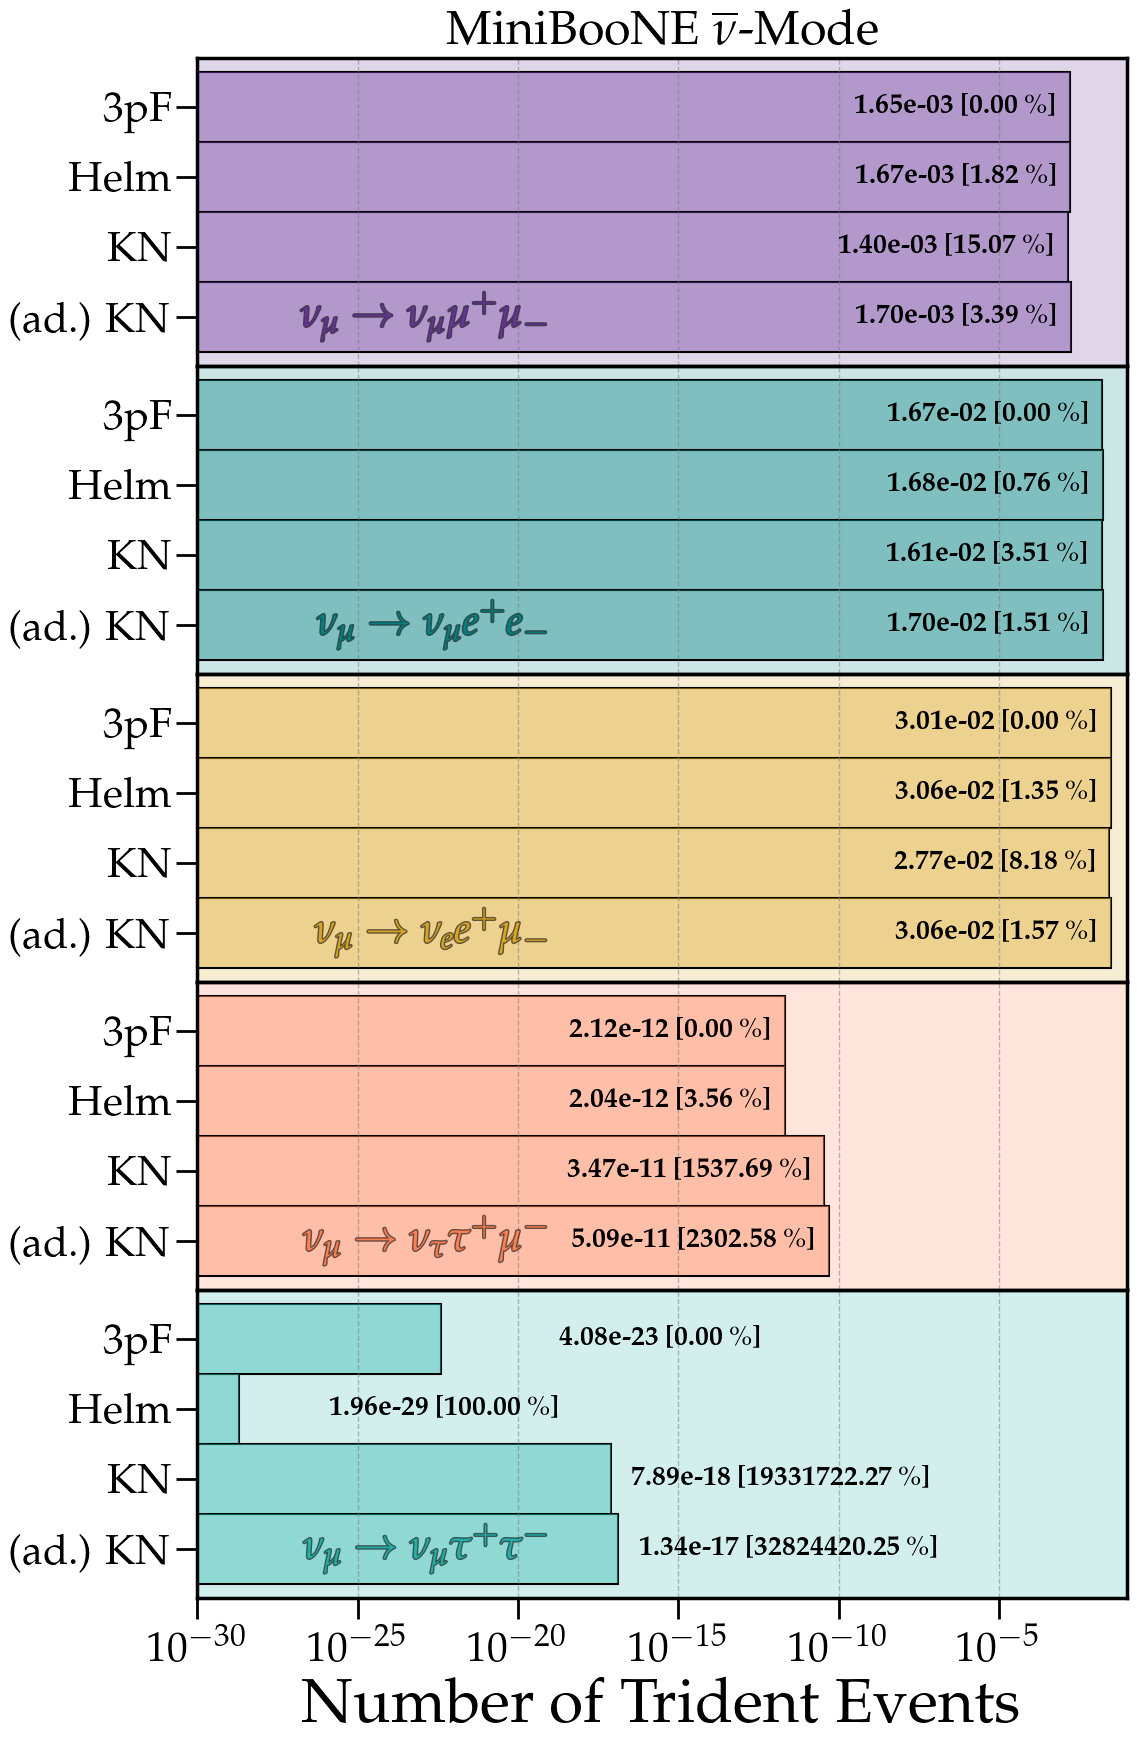

In [5]:
MD_MiniBooNE = 112
POT_MiniBooNE = 0.66
Total_Flux_MiniBooNE = 5.365346615405332e-07
ConvXsec_NuFlux_AntiNuMode_MiniBooNE = np.loadtxt('../csv/Conv_CrossSections/ConvXsec_nuflux_antinuMode_MiniBooNE')
NumOfEvents_NuFlux_AntiNuMode_MiniBooNE, Uncertainty_NuFlux_AntiNuMode_MiniBooNE = Compute_Trident_Events_Uncertainties(ConvXsec_NuFlux_AntiNuMode_MiniBooNE, MD_MiniBooNE, Total_Flux_MiniBooNE, POT_MiniBooNE)

Form_Factors = ['3pF', 'Helm', 'KN', '(ad.) KN']
Processes = [r'{\bf $\nu_\mu \to \nu_\mu \mu^{+} \mu_{-}$}',
             r'{\bf $\nu_\mu \to \nu_\mu e^{+} e_{-}$}',
             r'{\bf $\nu_\mu \to \nu_e e^{+} \mu_{-}$}',
             r'{\bf $\nu_\mu \to \nu_\tau \tau^{+} \mu^{-}$}',
             r'{\bf $\nu_\mu \to \nu_\mu \tau^{+} \tau^{-}$}']
Number_FormFactors = len(Form_Factors)
Number_Processes = len(Processes)

fig = plt.figure(figsize=(12,20))
gs = fig.add_gridspec(Number_Processes, hspace=0)
ax = gs.subplots(sharex=True, sharey=True)
cols = ['rebeccapurple', 'teal', 'goldenrod', 'coral', 'lightseagreen']

for i in range(len(NumOfEvents_NuFlux_AntiNuMode_MiniBooNE)):
    data = NumOfEvents_NuFlux_AntiNuMode_MiniBooNE[i]
    ax[i].barh(np.flipud(Form_Factors), np.flipud(data), left=0, align='center', height=1, edgecolor='k', facecolor='w', lw=1.5, zorder=-10, alpha=1)
    ax[i].barh(np.flipud(Form_Factors), np.flipud(data), left=0, xerr=0, align='center', height=0.98, facecolor=cols[i], lw=0, zorder=-10, alpha=0.5)
    ax[i].patch.set_facecolor(cols[i])
    ax[i].patch.set_alpha(0.2)


Correct_Position_Events = [0.4, 0.4, 0.4, 0.4, 1e10]
for i in range(len(NumOfEvents_NuFlux_AntiNuMode_MiniBooNE)):
    for j in range(len(NumOfEvents_NuFlux_AntiNuMode_MiniBooNE[0])):
        ax[i].text(Correct_Position_Events[i] * NumOfEvents_NuFlux_AntiNuMode_MiniBooNE[i][j], Number_FormFactors-1-j, r'{\bf %.2e [%.2f $\%%$]}' %
                   (NumOfEvents_NuFlux_AntiNuMode_MiniBooNE[i][j], Uncertainty_NuFlux_AntiNuMode_MiniBooNE[i][j]), va='center', ha='right', fontsize=20)


for i in range(len(ax)):
    ax[i].xaxis.grid(True, linestyle='--', which='major', color='grey', alpha=0.55)
    ax[i].tick_params(which='both', right=False, tickdir='out', top=False, bottom=False)
ax[-1].tick_params(which='both', right=False, tickdir='out', top=False, bottom=True)

for i in range(Number_Processes):
    ax[i].text(1e-19, 0, Processes[i], fontsize=30, alpha=1, color=cols[i], va='center', ha='right', rotation=0, path_effects=[pe.Stroke(linewidth=2, foreground='k', alpha=0.6), pe.Normal()])

ax[0].set_title(r'MiniBooNE $\overline{\nu}$-Mode')
ax[-1].set_xlabel(r'Number of Trident Events')
ax[-1].set_xscale('log')
ax[-1].set_xlim(left=1e-30, right=1e-1)

plt.savefig(r'../Plots/Figures_PDF/EventsatMiniBooNE_NuFlux_AntiNuMode.pdf', transparent=False, bbox_inches='tight')
plt.savefig(r'../Plots/Figures_PNG/EventsatMiniBooNE_NuFlux_AntiNuMode.png', transparent=False, bbox_inches='tight')

# SBND

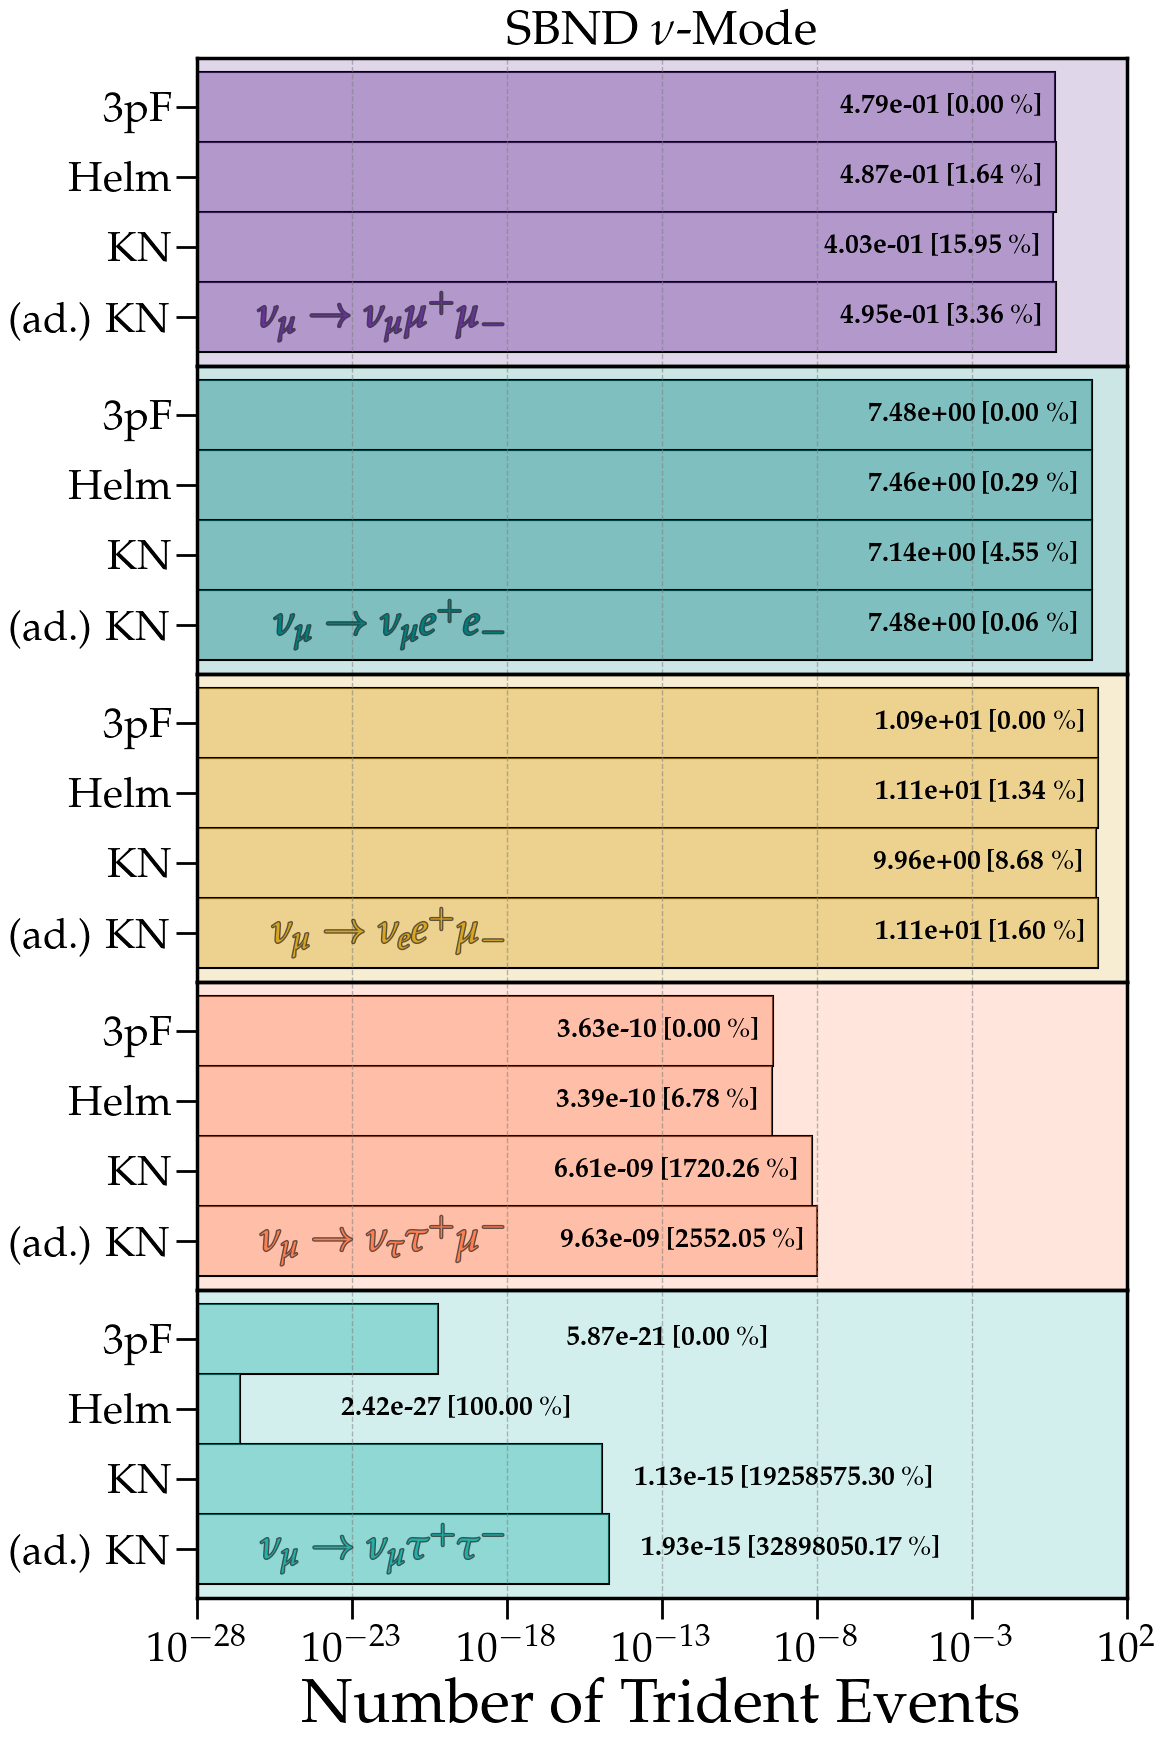

In [6]:
MD_SBND = 112
POT_SBND = 1
Total_Flux_SBND = 0.00016114069432666668
ConvXsec_NuFlux_NuMode_SBND = np.loadtxt('../csv/Conv_CrossSections/ConvXsec_nuflux_nuMode_SBND')
NumOfEvents_NuFlux_NuMode_SBND, Uncertainty_NuFlux_NuMode_SBND = Compute_Trident_Events_Uncertainties(ConvXsec_NuFlux_NuMode_SBND, MD_SBND, Total_Flux_SBND, POT_SBND)

Form_Factors = ['3pF', 'Helm', 'KN', '(ad.) KN']
Processes = [r'{\bf $\nu_\mu \to \nu_\mu \mu^{+} \mu_{-}$}',
             r'{\bf $\nu_\mu \to \nu_\mu e^{+} e_{-}$}',
             r'{\bf $\nu_\mu \to \nu_e e^{+} \mu_{-}$}',
             r'{\bf $\nu_\mu \to \nu_\tau \tau^{+} \mu^{-}$}',
             r'{\bf $\nu_\mu \to \nu_\mu \tau^{+} \tau^{-}$}']
Number_FormFactors = len(Form_Factors)
Number_Processes = len(Processes)

fig = plt.figure(figsize=(12,20))
gs = fig.add_gridspec(Number_Processes, hspace=0)
ax = gs.subplots(sharex=True, sharey=True)
cols = ['rebeccapurple', 'teal', 'goldenrod', 'coral', 'lightseagreen']

for i in range(len(NumOfEvents_NuFlux_NuMode_SBND)):
    data = NumOfEvents_NuFlux_NuMode_SBND[i]
    ax[i].barh(np.flipud(Form_Factors), np.flipud(data), left=0, align='center', height=1, edgecolor='k', facecolor='w', lw=1.5, zorder=-10, alpha=1)
    ax[i].barh(np.flipud(Form_Factors), np.flipud(data), left=0, xerr=0, align='center', height=0.98, facecolor=cols[i], lw=0, zorder=-10, alpha=0.5)
    ax[i].patch.set_facecolor(cols[i])
    ax[i].patch.set_alpha(0.2)


Correct_Position_Events = [0.4, 0.4, 0.4, 0.4, 5e10]
for i in range(len(NumOfEvents_NuFlux_NuMode_SBND)):
    for j in range(len(NumOfEvents_NuFlux_NuMode_SBND[0])):
        ax[i].text(Correct_Position_Events[i] * NumOfEvents_NuFlux_NuMode_SBND[i][j], Number_FormFactors-1-j, r'{\bf %.2e [%.2f $\%%$]}' %
                   (NumOfEvents_NuFlux_NuMode_SBND[i][j], Uncertainty_NuFlux_NuMode_SBND[i][j]), va='center', ha='right', fontsize=20)


for i in range(len(ax)):
    ax[i].xaxis.grid(True, linestyle='--', which='major', color='grey', alpha=0.55)
    ax[i].tick_params(which='both', right=False, tickdir='out', top=False, bottom=False)
ax[-1].tick_params(which='both', right=False, tickdir='out', top=False, bottom=True)

for i in range(Number_Processes):
    ax[i].text(1e-18, 0, Processes[i], fontsize=30, alpha=1, color=cols[i], va='center', ha='right', rotation=0, path_effects=[pe.Stroke(linewidth=2, foreground='k', alpha=0.6), pe.Normal()])

ax[0].set_title(r'SBND $\nu$-Mode')
ax[-1].set_xlabel(r'Number of Trident Events')
ax[-1].set_xscale('log')
ax[-1].set_xlim(left=1e-28, right=100)

plt.savefig(r'../Plots/Figures_PDF/EventsatSBND_NuFlux_NuMode.pdf', transparent=False, bbox_inches='tight')
plt.savefig(r'../Plots/Figures_PNG/EventsatSBND_NuFlux_NuMode.png', transparent=False, bbox_inches='tight')

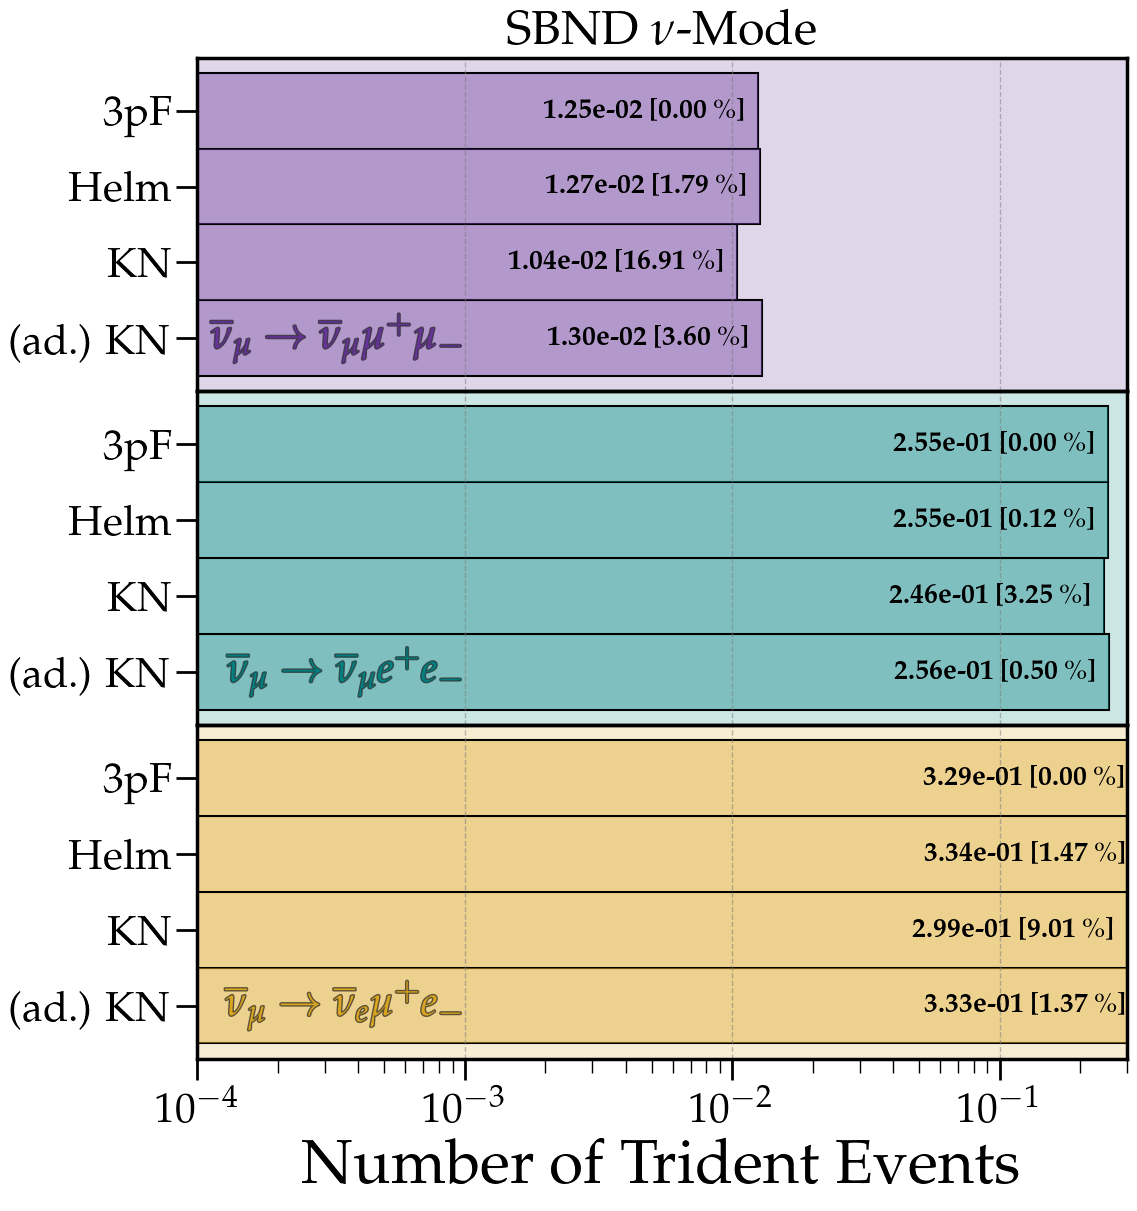

In [7]:
MD_SBND = 112
POT_SBND = 1
Total_Flux_SBND = 1.1709089422666665e-05
ConvXsec_AntiNuFlux_NuMode_SBND = np.loadtxt('../csv/Conv_CrossSections/ConvXsec_antinuflux_nuMode_SBND')
NumOfEvents_AntiNuFlux_NuMode_SBND, Uncertainty_AntiNuFlux_NuMode_SBND = Compute_Trident_Events_Uncertainties(ConvXsec_AntiNuFlux_NuMode_SBND, MD_SBND, Total_Flux_SBND, POT_SBND)

Form_Factors = ['3pF', 'Helm', 'KN', '(ad.) KN']
Processes = [r'{\bf $\overline{\nu}_\mu \to \overline{\nu}_\mu \mu^{+} \mu_{-}$}',
             r'{\bf $\overline{\nu}_\mu \to \overline{\nu}_\mu e^{+} e_{-}$}',
             r'{\bf $\overline{\nu}_\mu \to \overline{\nu}_e \mu^{+} e_{-}$}']
Number_FormFactors = len(Form_Factors)
Number_Processes = len(Processes)

fig = plt.figure(figsize=(12,13))
gs = fig.add_gridspec(Number_Processes, hspace=0)
ax = gs.subplots(sharex=True, sharey=True)
cols = ['rebeccapurple', 'teal', 'goldenrod']

for i in range(len(NumOfEvents_AntiNuFlux_NuMode_SBND)):
    data = NumOfEvents_AntiNuFlux_NuMode_SBND[i]
    ax[i].barh(np.flipud(Form_Factors), np.flipud(data), left=0, align='center', height=1, edgecolor='k', facecolor='w', lw=1.5, zorder=-10, alpha=1)
    ax[i].barh(np.flipud(Form_Factors), np.flipud(data), left=0, xerr=0, align='center', height=0.98, facecolor=cols[i], lw=0, zorder=-10, alpha=0.5)
    ax[i].patch.set_facecolor(cols[i])
    ax[i].patch.set_alpha(0.2)


Correct_Position_Events = [0.9, 0.9, 0.9]
for i in range(len(NumOfEvents_AntiNuFlux_NuMode_SBND)):
    for j in range(len(NumOfEvents_AntiNuFlux_NuMode_SBND[0])):
        ax[i].text(Correct_Position_Events[i] * NumOfEvents_AntiNuFlux_NuMode_SBND[i][j], Number_FormFactors-1-j, r'{\bf %.2e [%.2f $\%%$]}' %
                   (NumOfEvents_AntiNuFlux_NuMode_SBND[i][j], Uncertainty_AntiNuFlux_NuMode_SBND[i][j]), va='center', ha='right', fontsize=20)


for i in range(len(ax)):
    ax[i].xaxis.grid(True, linestyle='--', which='major', color='grey', alpha=0.55)
    ax[i].tick_params(which='both', right=False, tickdir='out', top=False, bottom=False)
ax[-1].tick_params(which='both', right=False, tickdir='out', top=False, bottom=True)

for i in range(Number_Processes):
    ax[i].text(1e-3, 0, Processes[i], fontsize=30, alpha=1, color=cols[i], va='center', ha='right', rotation=0, path_effects=[pe.Stroke(linewidth=2, foreground='k', alpha=0.6), pe.Normal()])

ax[0].set_title(r'SBND $\nu$-Mode')
ax[-1].set_xlabel(r'Number of Trident Events')
ax[-1].set_xscale('log')
ax[-1].set_xlim(left=1e-4, right=0.3)

plt.savefig(r'../Plots/Figures_PDF/EventsatSBND_AntiNuFlux_NuMode.pdf', transparent=False, bbox_inches='tight')
plt.savefig(r'../Plots/Figures_PNG/EventsatSBND_AntiNuFlux_NuMode.png', transparent=False, bbox_inches='tight')

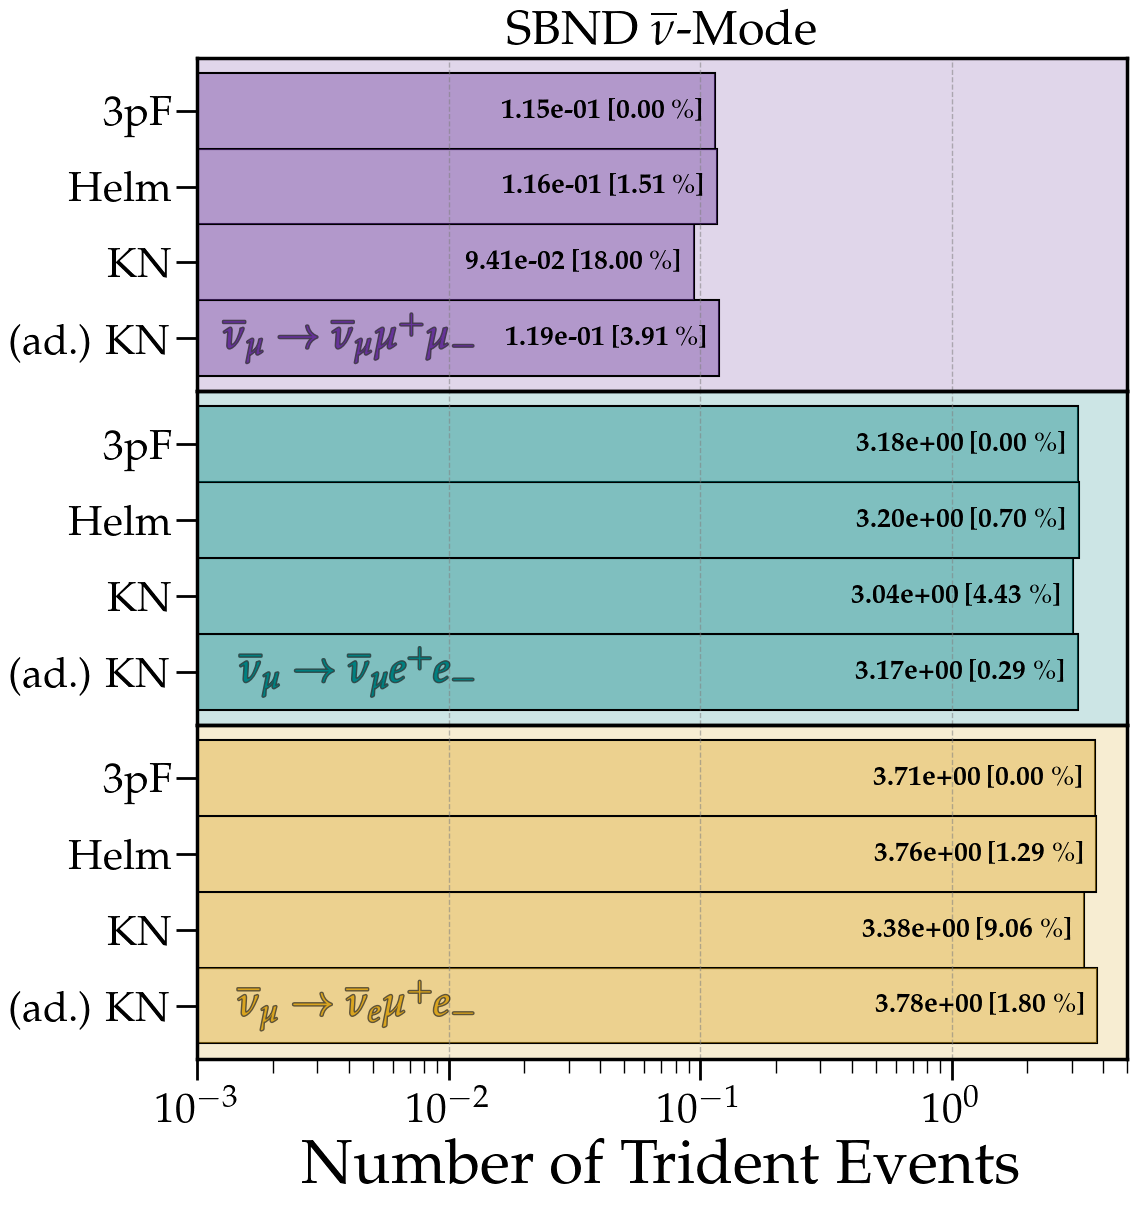

In [8]:
MD_SBND = 112
POT_SBND = 1
Total_Flux_SBND = 8.782506499594861e-05
ConvXsec_AntiNuFlux_AntiNuMode_SBND = np.loadtxt('../csv/Conv_CrossSections/ConvXsec_antinuflux_antinuMode_SBND')
NumOfEvents_AntiNuFlux_AntiNuMode_SBND, Uncertainty_AntiNuFlux_AntiNuMode_SBND = Compute_Trident_Events_Uncertainties(ConvXsec_AntiNuFlux_AntiNuMode_SBND, MD_SBND, Total_Flux_SBND, POT_SBND)

Form_Factors = ['3pF', 'Helm', 'KN', '(ad.) KN']
Processes = [r'{\bf $\overline{\nu}_\mu \to \overline{\nu}_\mu \mu^{+} \mu_{-}$}',
             r'{\bf $\overline{\nu}_\mu \to \overline{\nu}_\mu e^{+} e_{-}$}',
             r'{\bf $\overline{\nu}_\mu \to \overline{\nu}_e \mu^{+} e_{-}$}']
Number_FormFactors = len(Form_Factors)
Number_Processes = len(Processes)

fig = plt.figure(figsize=(12,13))
gs = fig.add_gridspec(Number_Processes, hspace=0)
ax = gs.subplots(sharex=True, sharey=True)
cols = ['rebeccapurple', 'teal', 'goldenrod']

for i in range(len(NumOfEvents_AntiNuFlux_AntiNuMode_SBND)):
    data = NumOfEvents_AntiNuFlux_AntiNuMode_SBND[i]
    ax[i].barh(np.flipud(Form_Factors), np.flipud(data), left=0, align='center', height=1, edgecolor='k', facecolor='w', lw=1.5, zorder=-10, alpha=1)
    ax[i].barh(np.flipud(Form_Factors), np.flipud(data), left=0, xerr=0, align='center', height=0.98, facecolor=cols[i], lw=0, zorder=-10, alpha=0.5)
    ax[i].patch.set_facecolor(cols[i])
    ax[i].patch.set_alpha(0.2)


Correct_Position_Events = [0.9, 0.9, 0.9]
for i in range(len(NumOfEvents_AntiNuFlux_AntiNuMode_SBND)):
    for j in range(len(NumOfEvents_AntiNuFlux_AntiNuMode_SBND[0])):
        ax[i].text(Correct_Position_Events[i] * NumOfEvents_AntiNuFlux_AntiNuMode_SBND[i][j], Number_FormFactors-1-j, r'{\bf %.2e [%.2f $\%%$]}' %
                   (NumOfEvents_AntiNuFlux_AntiNuMode_SBND[i][j], Uncertainty_AntiNuFlux_AntiNuMode_SBND[i][j]), va='center', ha='right', fontsize=20)


for i in range(len(ax)):
    ax[i].xaxis.grid(True, linestyle='--', which='major', color='grey', alpha=0.55)
    ax[i].tick_params(which='both', right=False, tickdir='out', top=False, bottom=False)
ax[-1].tick_params(which='both', right=False, tickdir='out', top=False, bottom=True)

for i in range(Number_Processes):
    ax[i].text(1.3e-2, 0, Processes[i], fontsize=30, alpha=1, color=cols[i], va='center', ha='right', rotation=0, path_effects=[pe.Stroke(linewidth=2, foreground='k', alpha=0.6), pe.Normal()])

ax[0].set_title(r'SBND $\overline{\nu}$-Mode')
ax[-1].set_xlabel(r'Number of Trident Events')
ax[-1].set_xscale('log')
ax[-1].set_xlim(left=1e-3, right=5)

plt.savefig(r'../Plots/Figures_PDF/EventsatSBND_AntiNuFlux_AntiNuMode.pdf', transparent=False, bbox_inches='tight')
plt.savefig(r'../Plots/Figures_PNG/EventsatSBND_AntiNuFlux_AntiNuMode.png', transparent=False, bbox_inches='tight')

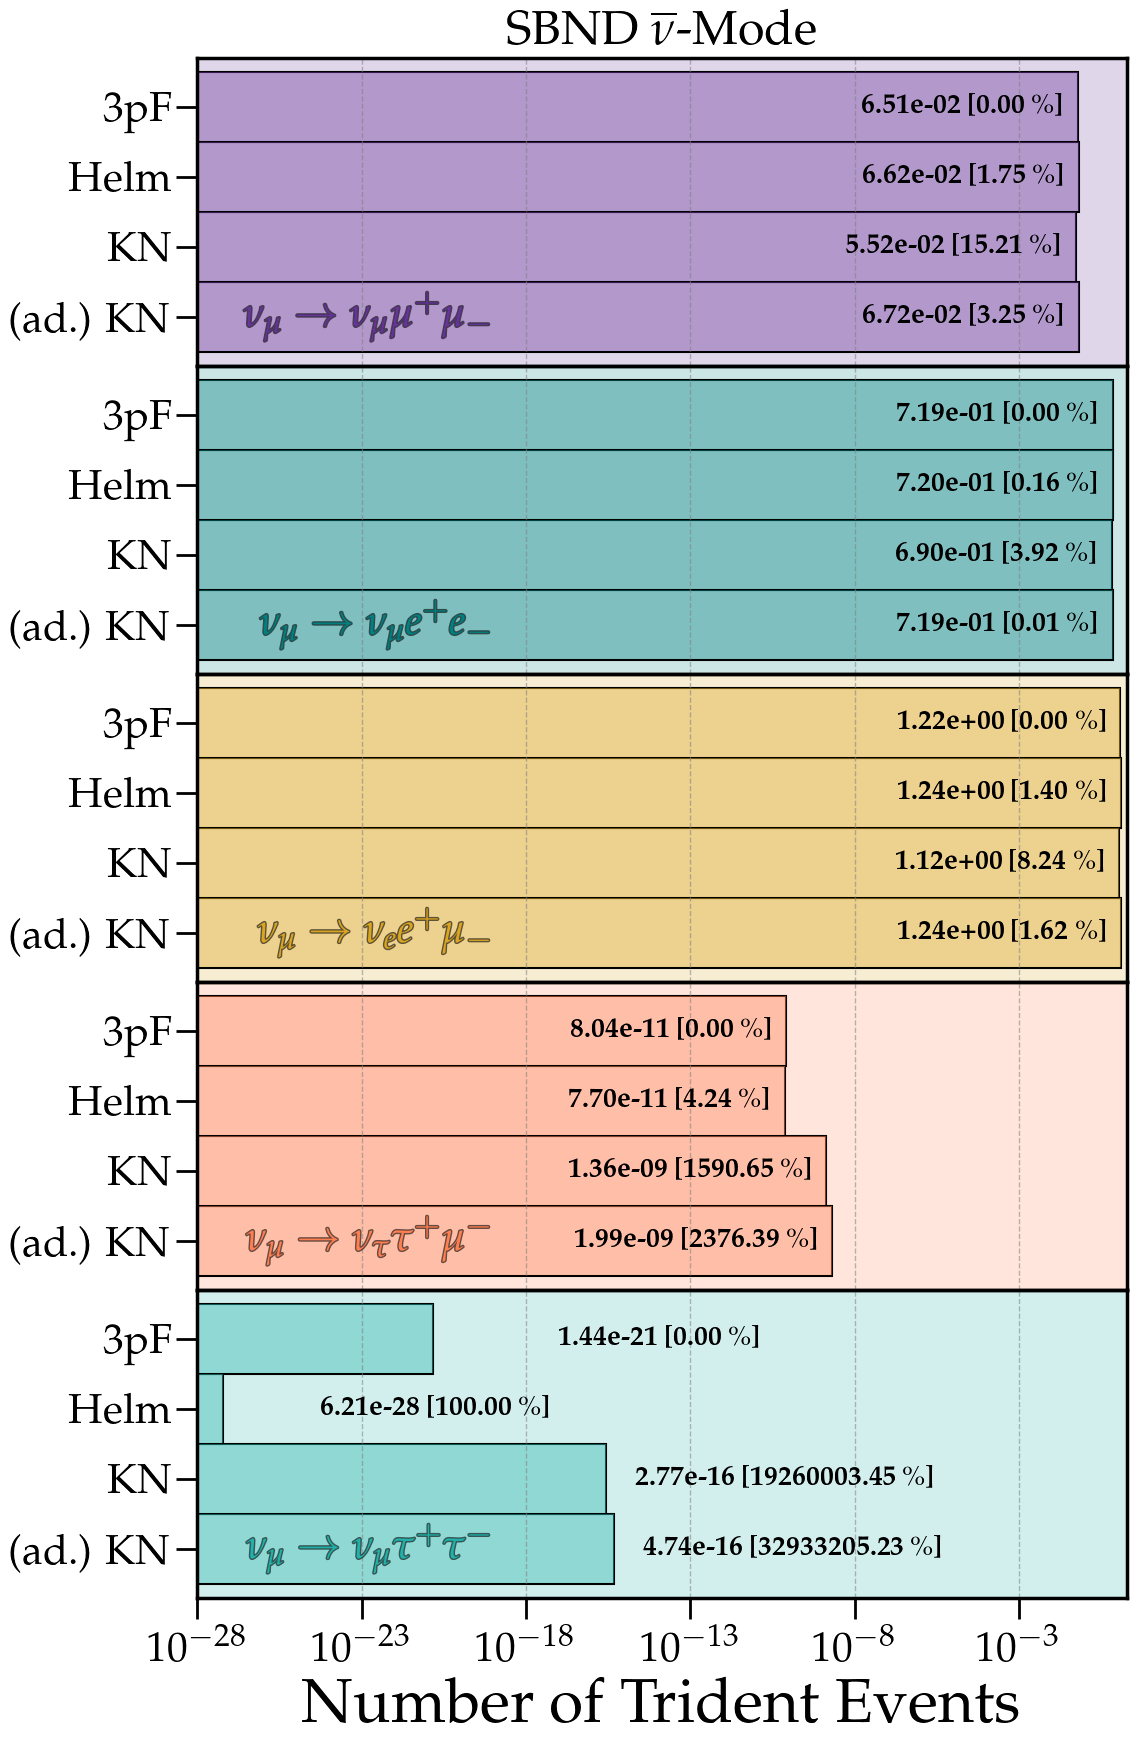

In [9]:
MD_SBND = 112
POT_SBND = 1
Total_Flux_SBND = 1.5891932893480667e-05
ConvXsec_NuFlux_AntiNuMode_SBND = np.loadtxt('../csv/Conv_CrossSections/ConvXsec_nuflux_antinuMode_SBND')
NumOfEvents_NuFlux_AntiNuMode_SBND, Uncertainty_NuFlux_AntiNuMode_SBND = Compute_Trident_Events_Uncertainties(ConvXsec_NuFlux_AntiNuMode_SBND, MD_SBND, Total_Flux_SBND, POT_SBND)

Form_Factors = ['3pF', 'Helm', 'KN', '(ad.) KN']
Processes = [r'{\bf $\nu_\mu \to \nu_\mu \mu^{+} \mu_{-}$}',
             r'{\bf $\nu_\mu \to \nu_\mu e^{+} e_{-}$}',
             r'{\bf $\nu_\mu \to \nu_e e^{+} \mu_{-}$}',
             r'{\bf $\nu_\mu \to \nu_\tau \tau^{+} \mu^{-}$}',
             r'{\bf $\nu_\mu \to \nu_\mu \tau^{+} \tau^{-}$}']
Number_FormFactors = len(Form_Factors)
Number_Processes = len(Processes)

fig = plt.figure(figsize=(12,20))
gs = fig.add_gridspec(Number_Processes, hspace=0)
ax = gs.subplots(sharex=True, sharey=True)
cols = ['rebeccapurple', 'teal', 'goldenrod', 'coral', 'lightseagreen']

for i in range(len(NumOfEvents_NuFlux_AntiNuMode_SBND)):
    data = NumOfEvents_NuFlux_AntiNuMode_SBND[i]
    ax[i].barh(np.flipud(Form_Factors), np.flipud(data), left=0, align='center', height=1, edgecolor='k', facecolor='w', lw=1.5, zorder=-10, alpha=1)
    ax[i].barh(np.flipud(Form_Factors), np.flipud(data), left=0, xerr=0, align='center', height=0.98, facecolor=cols[i], lw=0, zorder=-10, alpha=0.5)
    ax[i].patch.set_facecolor(cols[i])
    ax[i].patch.set_alpha(0.2)


Correct_Position_Events = [0.4, 0.4, 0.4, 0.4, 1e10]
for i in range(len(NumOfEvents_NuFlux_AntiNuMode_SBND)):
    for j in range(len(NumOfEvents_NuFlux_AntiNuMode_SBND[0])):
        ax[i].text(Correct_Position_Events[i] * NumOfEvents_NuFlux_AntiNuMode_SBND[i][j], Number_FormFactors-1-j, r'{\bf %.2e [%.2f $\%%$]}' %
                   (NumOfEvents_NuFlux_AntiNuMode_SBND[i][j], Uncertainty_NuFlux_AntiNuMode_SBND[i][j]), va='center', ha='right', fontsize=20)


for i in range(len(ax)):
    ax[i].xaxis.grid(True, linestyle='--', which='major', color='grey', alpha=0.55)
    ax[i].tick_params(which='both', right=False, tickdir='out', top=False, bottom=False)
ax[-1].tick_params(which='both', right=False, tickdir='out', top=False, bottom=True)

for i in range(Number_Processes):
    ax[i].text(1e-19, 0, Processes[i], fontsize=30, alpha=1, color=cols[i], va='center', ha='right', rotation=0, path_effects=[pe.Stroke(linewidth=2, foreground='k', alpha=0.6), pe.Normal()])

ax[0].set_title(r'SBND $\overline{\nu}$-Mode')
ax[-1].set_xlabel(r'Number of Trident Events')
ax[-1].set_xscale('log')
ax[-1].set_xlim(left=1e-28, right=2)

plt.savefig(r'../Plots/Figures_PDF/EventsatSBND_NuFlux_AntiNuMode.pdf', transparent=False, bbox_inches='tight')
plt.savefig(r'../Plots/Figures_PNG/EventsatSBND_NuFlux_AntiNuMode.png', transparent=False, bbox_inches='tight')

# DUNE Std CP

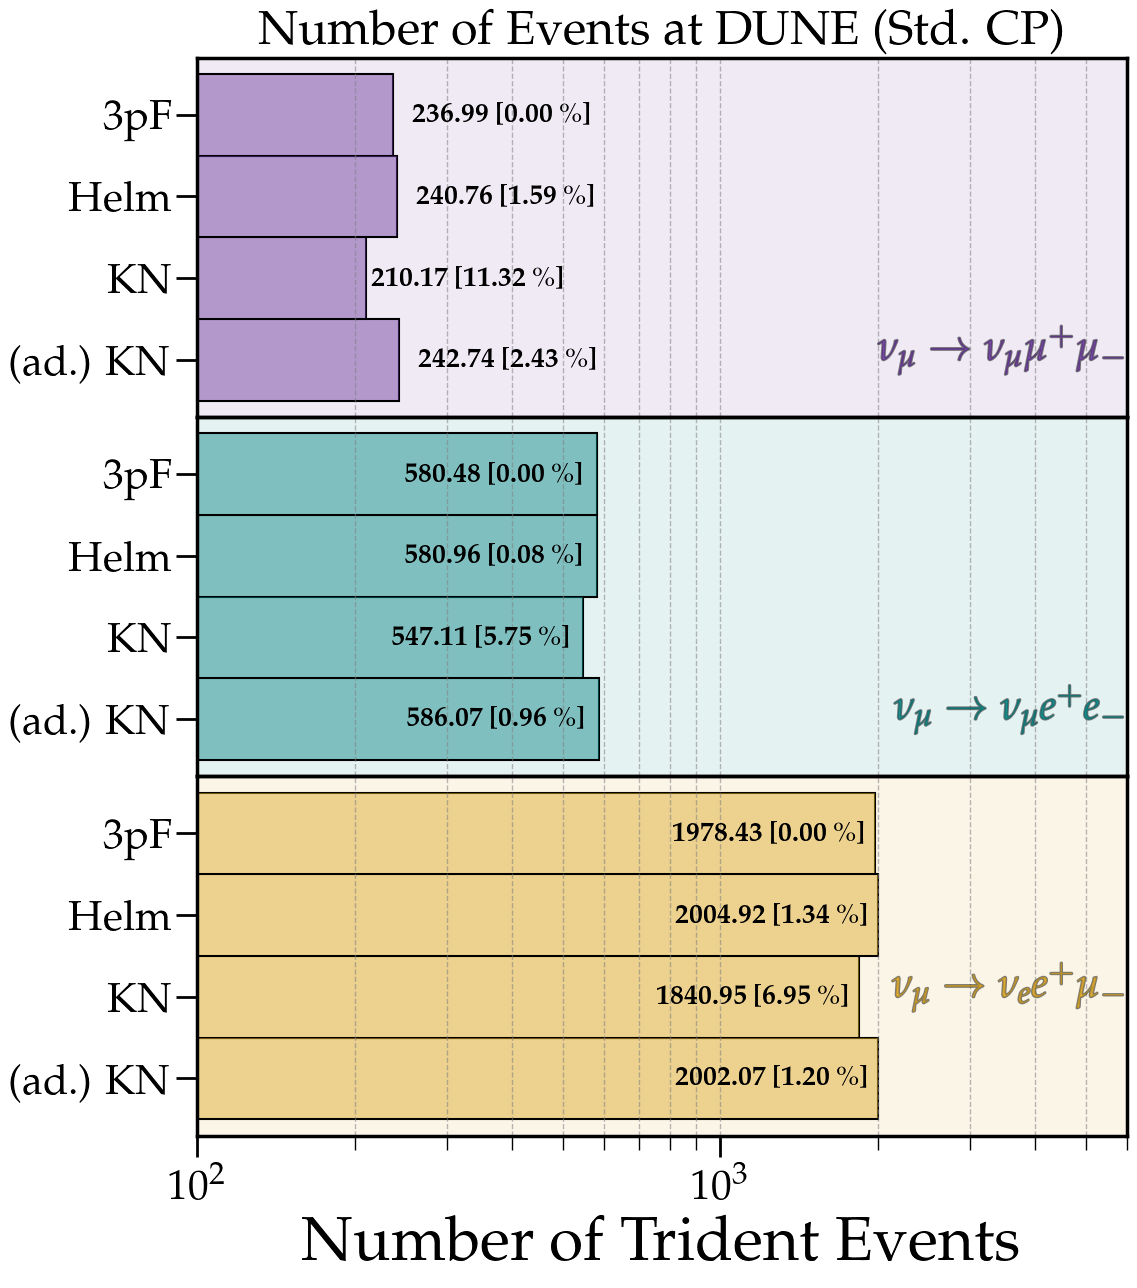

In [10]:
Form_Factors = ['3pF', 'Helm', 'KN', '(ad.) KN']
Number_FormFactors = len(Form_Factors)
Processes = [r'{\bf $\nu_\mu \to \nu_\mu \mu^{+} \mu_{-}$}', r'{\bf $\nu_\mu \to \nu_\mu e^{+} e_{-}$}', r'{\bf $\nu_\mu \to \nu_e e^{+} \mu_{-}$}']
Number_Processes = len(Processes)
fig = plt.figure(figsize=(12,14))
gs = fig.add_gridspec(Number_Processes, hspace=0)
ax1, ax2, ax3 = gs.subplots(sharex=True, sharey=True)
cols = ['rebeccapurple', 'teal', 'goldenrod']

Events_DUNE_StdCP_Process1 = np.array([236.99025, 240.75775, 210.16678, 242.74467], dtype=np.float64)
Events_DUNE_StdCP_Process2 = np.array([580.48448, 580.95773, 547.11043, 586.06596], dtype=np.float64)
Events_DUNE_StdCP_Process3 = np.array([1978.42630, 2004.92442, 1840.94579, 2002.07452], dtype=np.float64)

Uncertainty_Events_DUNE_StdCP_Process1 = np.array([0.0, 1.59, 11.32, 2.43], dtype=np.float64)
Uncertainty_Events_DUNE_StdCP_Process2 = np.array([0.0, 0.08, 5.75, 0.96], dtype=np.float64)
Uncertainty_Events_DUNE_StdCP_Process3 = np.array([0.0, 1.34, 6.95, 1.20], dtype=np.float64)

for ax, data, data_err, col in zip([ax1,ax2,ax3], [Events_DUNE_StdCP_Process1,Events_DUNE_StdCP_Process2,Events_DUNE_StdCP_Process3], [Uncertainty_Events_DUNE_StdCP_Process1, Uncertainty_Events_DUNE_StdCP_Process2, Uncertainty_Events_DUNE_StdCP_Process3], cols):
    ax.barh(np.flipud(Form_Factors), np.flipud(data), left=0, align='center', height=1, edgecolor='k', facecolor='w', lw=1.5, zorder=-10, alpha=1)
    ax.barh(np.flipud(Form_Factors), np.flipud(data), left=0, xerr=0, align='center', height=0.98, facecolor=col, lw=0, zorder=-10, alpha=0.5)
    ax.patch.set_facecolor(col)
    ax.patch.set_alpha(0.1)

# Adding text labels
t_shift = [0.01, 0.01, 0.01, 0.0, 0.0]
for i in range(Number_FormFactors):
    ax1.text(2.4*Events_DUNE_StdCP_Process1[i], 3-i-t_shift[i], r'{\bf %.2f [%.2f $\%%$]}' % (Events_DUNE_StdCP_Process1[i], Uncertainty_Events_DUNE_StdCP_Process1[i]), va='center', ha='right', fontsize=20)
    ax2.text(0.95*Events_DUNE_StdCP_Process2[i], 3-i-t_shift[i], r'{\bf %.2f [%.2f $\%%$]}' % (Events_DUNE_StdCP_Process2[i], Uncertainty_Events_DUNE_StdCP_Process2[i]), va='center', ha='right', fontsize=20)
    ax3.text(0.96*Events_DUNE_StdCP_Process3[i], 3-i-t_shift[i], r'{\bf %.2f [%.2f $\%%$]}' % (Events_DUNE_StdCP_Process3[i], Uncertainty_Events_DUNE_StdCP_Process3[i]), va='center', ha='right', fontsize=20)

# Grid lines
ax1.xaxis.grid(True, linestyle='--', which='both', color='grey', alpha=0.55)
ax2.xaxis.grid(True, linestyle='--', which='both', color='grey', alpha=0.55)
ax3.xaxis.grid(True, linestyle='--', which='both', color='grey', alpha=0.55)


# Tick parameters
ax1.tick_params(which='both', right=False, tickdir='out', top=False, bottom=False)
ax2.tick_params(which='both', right=False, tickdir='out', top=False, bottom=False)
ax3.tick_params(which='both', right=False, tickdir='out', top=False)

# Labels
ax1.text(6000, 0.0, Processes[0], fontsize=30, alpha=0.7, color=cols[0], ha='right', rotation=0, path_effects=[pe.Stroke(linewidth=1.5, foreground='k', alpha=0.5), pe.Normal()])
ax2.text(6000, 0.0, Processes[1], fontsize=30, alpha=0.7, color=cols[1], ha='right', rotation=0, path_effects=[pe.Stroke(linewidth=1.5, foreground='k', alpha=0.5), pe.Normal()])
ax3.text(6000, 1.0, Processes[2], fontsize=30, alpha=0.7, color=cols[2], ha='right', rotation=0, path_effects=[pe.Stroke(linewidth=1.5, foreground='k', alpha=0.5), pe.Normal()])

ax1.set_title(r'Number of Events at DUNE (Std. CP)')
ax3.set_xlabel(r'Number of Trident Events')
ax3.set_xscale('log')
ax3.set_xlim(left=100, right=6000)
plt.savefig('../Plots/Figures_PDF/EventsatDUNE_StdCP.pdf', transparent=False, bbox_inches='tight')
plt.savefig('../Plots/Figures_PNG/EventsatDUNE_StdCP.png', transparent=False, bbox_inches='tight')

# DUNE Tau OPT

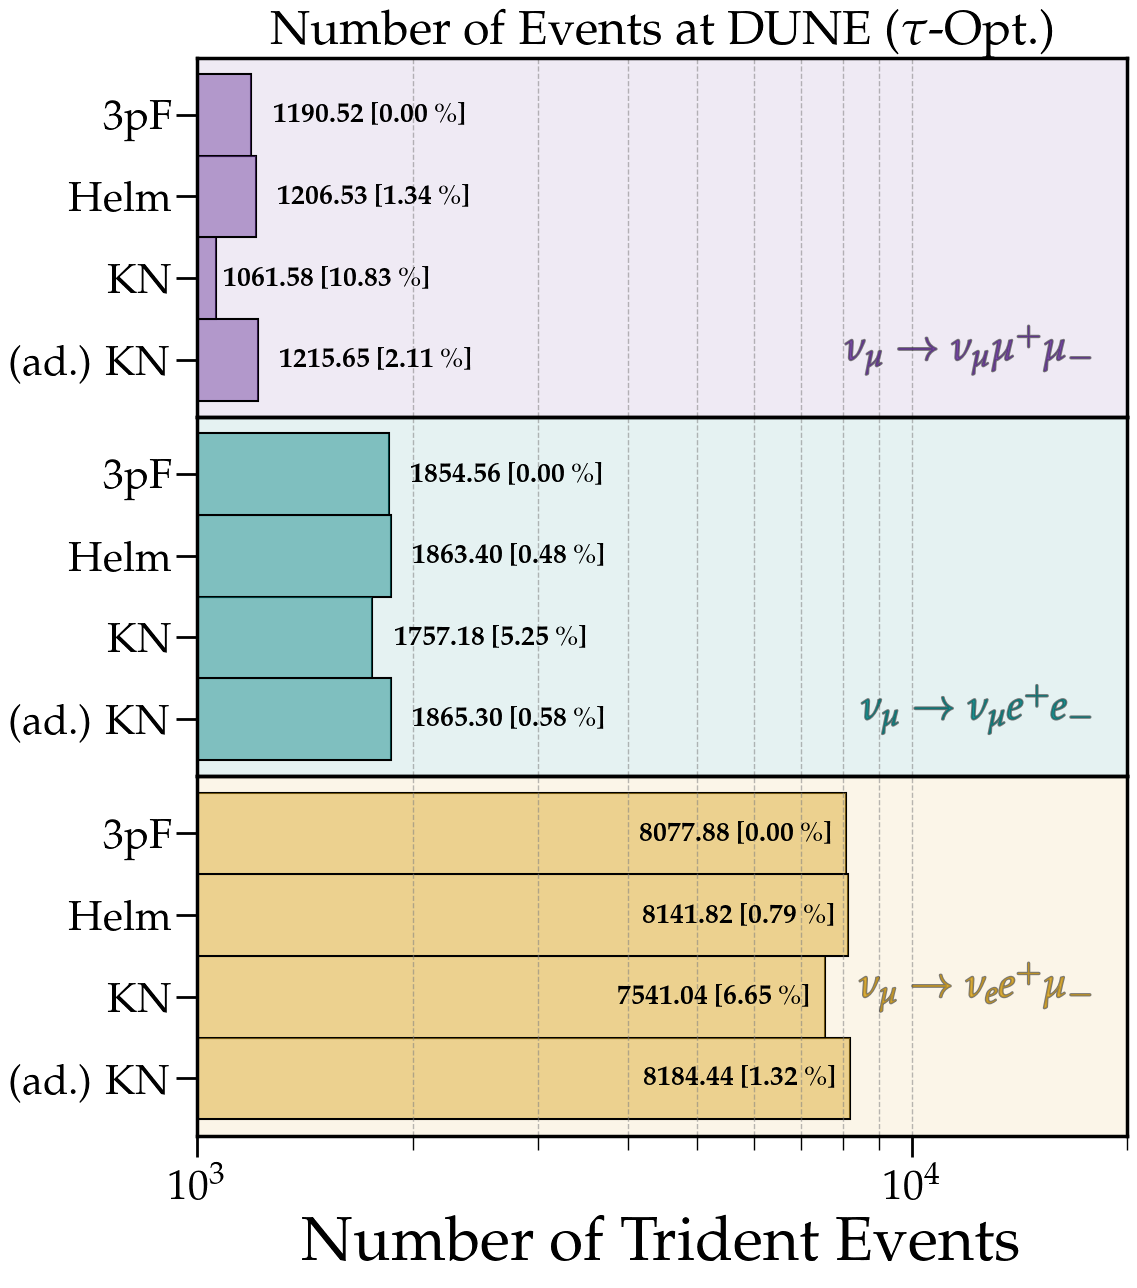

In [12]:
Form_Factors = ['3pF', 'Helm', 'KN', '(ad.) KN']
Number_FormFactors = len(Form_Factors)
Processes = [r'{\bf $\nu_\mu \to \nu_\mu \mu^{+} \mu_{-}$}', r'{\bf $\nu_\mu \to \nu_\mu e^{+} e_{-}$}', r'{\bf $\nu_\mu \to \nu_e e^{+} \mu_{-}$}']
Number_Processes = len(Processes)
fig = plt.figure(figsize=(12,14))
gs = fig.add_gridspec(Number_Processes, hspace=0)
ax1, ax2, ax3 = gs.subplots(sharex=True, sharey=True)
cols = ['rebeccapurple', 'teal', 'goldenrod']

Events_DUNE_TauOPT_Process1 = np.array([1190.52016, 1206.52585, 1061.57929, 1215.65174], dtype=np.float64)
Events_DUNE_TauOPT_Process2 = np.array([1854.55917, 1863.40190, 1757.17816, 1865.30361], dtype=np.float64)
Events_DUNE_TauOPT_Process3 = np.array([8077.87921, 8141.81778, 7541.04008, 8184.44350], dtype=np.float64)

Uncertainty_Events_DUNE_TauOPT_Process1 = np.array([0.0, 1.34, 10.83, 2.11], dtype=np.float64)
Uncertainty_Events_DUNE_TauOPT_Process2 = np.array([0.0, 0.48, 5.25, 0.58], dtype=np.float64)
Uncertainty_Events_DUNE_TauOPT_Process3 = np.array([0.0, 0.79, 6.65, 1.32], dtype=np.float64)

for ax, data, data_err, col in zip([ax1,ax2,ax3], [Events_DUNE_TauOPT_Process1,Events_DUNE_TauOPT_Process2,Events_DUNE_TauOPT_Process3], [Uncertainty_Events_DUNE_TauOPT_Process1, Uncertainty_Events_DUNE_TauOPT_Process2, Uncertainty_Events_DUNE_TauOPT_Process3], cols):
    ax.barh(np.flipud(Form_Factors), np.flipud(data), left=0, align='center', height=1, edgecolor='k', facecolor='w', lw=1.5, zorder=-10, alpha=1)
    ax.barh(np.flipud(Form_Factors), np.flipud(data), left=0, xerr=0, align='center', height=0.98, facecolor=col, lw=0, zorder=-10, alpha=0.5)
    ax.patch.set_facecolor(col)
    ax.patch.set_alpha(0.1)

# Adding text labels
t_shift = [0.01, 0.01, 0.01, 0.0, 0.0]
for i in range(Number_FormFactors):
    ax1.text(2*Events_DUNE_TauOPT_Process1[i], 3-i-t_shift[i], r'{\bf %.2f [%.2f $\%%$]}' % (Events_DUNE_TauOPT_Process1[i], Uncertainty_Events_DUNE_TauOPT_Process1[i]), va='center', ha='right', fontsize=20)
    ax2.text(2*Events_DUNE_TauOPT_Process2[i], 3-i-t_shift[i], r'{\bf %.2f [%.2f $\%%$]}' % (Events_DUNE_TauOPT_Process2[i], Uncertainty_Events_DUNE_TauOPT_Process2[i]), va='center', ha='right', fontsize=20)
    ax3.text(0.96*Events_DUNE_TauOPT_Process3[i], 3-i-t_shift[i], r'{\bf %.2f [%.2f $\%%$]}' % (Events_DUNE_TauOPT_Process3[i], Uncertainty_Events_DUNE_TauOPT_Process3[i]), va='center', ha='right', fontsize=20)

# Grid lines
ax1.xaxis.grid(True, linestyle='--', which='both', color='grey', alpha=0.55)
ax2.xaxis.grid(True, linestyle='--', which='both', color='grey', alpha=0.55)
ax3.xaxis.grid(True, linestyle='--', which='both', color='grey', alpha=0.55)


# Tick parameters
ax1.tick_params(which='both', right=False, tickdir='out', top=False, bottom=False)
ax2.tick_params(which='both', right=False, tickdir='out', top=False, bottom=False)
ax3.tick_params(which='both', right=False, tickdir='out', top=False)

# Labels
ax1.text(18000, 0.0, Processes[0], fontsize=30, alpha=0.7, color=cols[0], ha='right', rotation=0, path_effects=[pe.Stroke(linewidth=1.5, foreground='k', alpha=0.5), pe.Normal()])
ax2.text(18000, 0.0, Processes[1], fontsize=30, alpha=0.7, color=cols[1], ha='right', rotation=0, path_effects=[pe.Stroke(linewidth=1.5, foreground='k', alpha=0.5), pe.Normal()])
ax3.text(18000, 1.0, Processes[2], fontsize=30, alpha=0.7, color=cols[2], ha='right', rotation=0, path_effects=[pe.Stroke(linewidth=1.5, foreground='k', alpha=0.5), pe.Normal()])

ax1.set_title(r'Number of Events at DUNE ($\tau$-Opt.)')
ax3.set_xlabel(r'Number of Trident Events')
ax3.set_xscale('log')
ax3.set_xlim(left=1000, right=20000)
plt.savefig('../Plots/Figures_PDF/EventsatDUNE_TauOPT.pdf', transparent=False, bbox_inches='tight')
plt.savefig('../Plots/Figures_PNG/EventsatDUNE_TauOPT.png', transparent=False, bbox_inches='tight')